In [1]:
import os

# ============================================================
# ENVIRONMENT SETUP
# ============================================================
# Option 1: Google Colab + Drive (default)
# Option 2: Local — place dataset at ./data/DATA_CLEAN/
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATASET_PATH = '/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN'
else:
    DATASET_PATH = os.path.join(os.getcwd(), 'data', 'DATA_CLEAN')

IMAGES_PATH = os.path.join(DATASET_PATH, 'images')
LABELS_PATH = os.path.join(DATASET_PATH, 'labels')

print(f"Environment  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Dataset path : {DATASET_PATH}")
print(f"Exists       : {os.path.exists(DATASET_PATH)}")

Mounted at /content/drive
Environment  : Google Colab
Dataset path : /content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN
Exists       : True


# Part A — Improve the Detector (in a notebook)



### Week-1 Baseline Results (yolo26s, 30 epochs)

In the first assessment, I trained a YOLOv26s model on the cat detection
dataset for 30 epochs using a T4 GPU on Google Colab. The model was trained
from COCO-pretrained weights and evaluated on a held-out test split.
The results were quite promising for a baseline run:

| Metric | Value |
|---|---|
| mAP@0.5 | 0.9055 |
| mAP@0.5:0.95 | 0.6988 |
| Precision | 0.8895 |
| Recall | 0.8673 |

Overall, the model performed well on clean, clearly visible cats. However,
after analysing the failure cases in Task 5, I identified two specific
weaknesses.

### Weakness 1 — Occlusion and Partial Visibility

In several test images, the cat was partially hidden — either pressed against
a person's chest, peeking above a wall, or obscured by furniture. In these
cases the model consistently failed to produce a detection, resulting in false
negatives. I believe this happened because the model rarely saw heavily
occluded cats during training and therefore never learned to detect them
from partial cues alone.

### Weakness 2 — Human-Cat Confusion in Close-Up Scenes

In one notable failure case, the model drew a bounding box around a child
leaning over a cat and confidently labelled it as a cat (confidence 0.87).
The child's dark hair and hunched posture closely resembled a cat's silhouette
in that particular angle, and the proximity to a real cat in the same frame
likely reinforced the false detection. This suggests the model has not yet
learned to reliably distinguish between feline and human features in
ambiguous, close-range compositions.

# 2. Pick at least three Week-2 techniques


## Run 1 — Two-Stage Transfer Learning + Stronger Augmentation + Cosine LR

### Why this combination?

**Two-Stage Transfer Learning — freeze backbone → unfreeze with lower LR**
yolo26s arrives pretrained on COCO with a backbone that already detects
edges, textures, and object parts. When the full network is fine-tuned
from epoch 0, the large early loss from the randomly initialised detection
head flows back into the backbone and corrupts those pretrained features
before the head has had time to stabilise. Two-stage training prevents
this: Stage 1 freezes the first 10 layers (backbone) for 10 epochs at
lr0=0.01 — only the detection head trains, quickly learning what a cat
looks like from the existing feature maps. Stage 2 unfreezes all layers
at a much smaller lr0=0.001 — the backbone can now adapt its features to
the cat domain without the risk of catastrophic forgetting that comes from
a large learning rate on a previously frozen network.

**Stronger Augmentation — mosaic, copy_paste, mixup, geometric transforms**
Week-1 failure cases showed the model missing partially occluded cats.
copy_paste=0.3 synthetically creates occlusion by pasting cat instances
from other images onto the current one. mixup=0.15 blends two images
together, forcing the model to handle ambiguous overlapping scenes.
Geometric transforms (degrees, translate, scale, flipud) add viewpoint
and scale diversity across the training batches.

**Cosine LR Schedule**
cos_lr=True is applied in both stages for different reasons. In Stage 1
it provides stable convergence for the head-only warm-up. In Stage 2 it
gives a smooth annealing tail — the learning rate decays gradually toward
zero, allowing the unfrozen backbone to fine-tune its features without
large oscillations in the final epochs.

### Hyperparameter Justification

**Stage 1 parameters:**
- `freeze=10` — first 10 layers cover the backbone; freezing them lets
  the detection head stabilise before any backbone gradients are applied
- `epochs=10` — short warm-up; just enough for the head to learn basic
  cat features from pretrained COCO feature maps
- `lr0=0.01` — higher LR is safe here since only the head trains;
  faster convergence for the head-only stage
- `batch=32` — yolo26s is lightweight; batch=32 fits T4 VRAM and gives
  stable gradient estimates

**Stage 2 parameters:**
- `freeze=0` — full network trains; backbone adapts to cat domain
- `epochs=60` — Week-1 logs showed loss still declining at epoch 30;
  doubling the budget allows full convergence
- `lr0=0.001` — 10x smaller than Stage 1 to protect pretrained backbone
  features from large gradient updates
- `cos_lr=True` — cosine annealing provides smooth LR decay; rapid
  coarse alignment early, gradual fine-tuning in final epochs
- `mosaic=1.0` — default mosaic kept; tiles 4 images into one,
  mechanically producing more small/partial cat examples per batch
- `copy_paste=0.3` — 30% chance of pasting cat instances from other
  images; directly creates synthetic occlusion scenarios
- `mixup=0.15` — blends 15% of batches with a second image; regularises
  against overconfident predictions in ambiguous scenes
- `degrees=10.0` — random rotation ±10°; adds viewpoint diversity
- `translate=0.15` — random translation ±15%; helps detect cats near
  image edges
- `scale=0.6` — random scale [0.4×, 1.6×]; improves robustness to
  cats at different distances
- `flipud=0.1` — 10% vertical flip; rare in real scenes but present
  in dataset (cats photographed from above)
- `fliplr=0.5` — 50% horizontal flip; standard augmentation, cats
  are symmetric
- `weight_decay=0.0005` — default AdamW weight decay; mild
  regularisation against overfitting on the 2328-image training set
- `batch=32` — same as Stage 1; consistent effective LR scale

In [ ]:
from ultralytics import YOLO
import os

yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
runs_dir = '/content/drive/MyDrive/cat_detection_dataset/runs'

# ── Run 2, Stage 1: frozen backbone ─────────────────────────────────────────
model_v2_r2 = YOLO("yolo26s.pt")

results_stage1 = model_v2_r2.train(
    data       = yaml_path,
    epochs     = 10,
    imgsz      = 640,
    batch      = 32,
    freeze     = 10,
    lr0        = 0.01,
    cos_lr     = True,
    mosaic     = 1.0,
    copy_paste = 0.3,
    mixup      = 0.15,
    degrees    = 10.0,
    translate  = 0.15,
    scale      = 0.6,
    flipud     = 0.1,
    fliplr     = 0.5,
    project    = runs_dir,
    name       = "cats_v2_run2_stage1",
    seed       = 42,
    device     = 0,
)
print("Stage 1 complete.")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/cat_dataset_local/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v2_run2_stage1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [ ]:
# ── Run 2, Stage 2: full unfreeze ────────────────────────────────────────────
stage1_weights = os.path.join(
    runs_dir, 'cats_v2_run2_stage1', 'weights', 'last.pt'
)
model_v2_r2_full = YOLO(stage1_weights)

results_stage2 = model_v2_r2_full.train(
    data       = yaml_path,
    epochs     = 60,
    imgsz      = 640,
    batch      = 32,
    freeze     = 0,
    lr0        = 0.001,
    cos_lr     = True,
    mosaic     = 1.0,
    copy_paste = 0.3,
    mixup      = 0.15,
    degrees    = 10.0,
    translate  = 0.15,
    scale      = 0.6,
    flipud     = 0.1,
    fliplr     = 0.5,
    project    = runs_dir,
    name       = "cats_v2_run2_stage2",
    seed       = 42,
    device     = 0,
)
print("Stage 2 complete.")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/cat_dataset_local/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage1/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v2_run2_stage2, nbs

# The training/validation curves

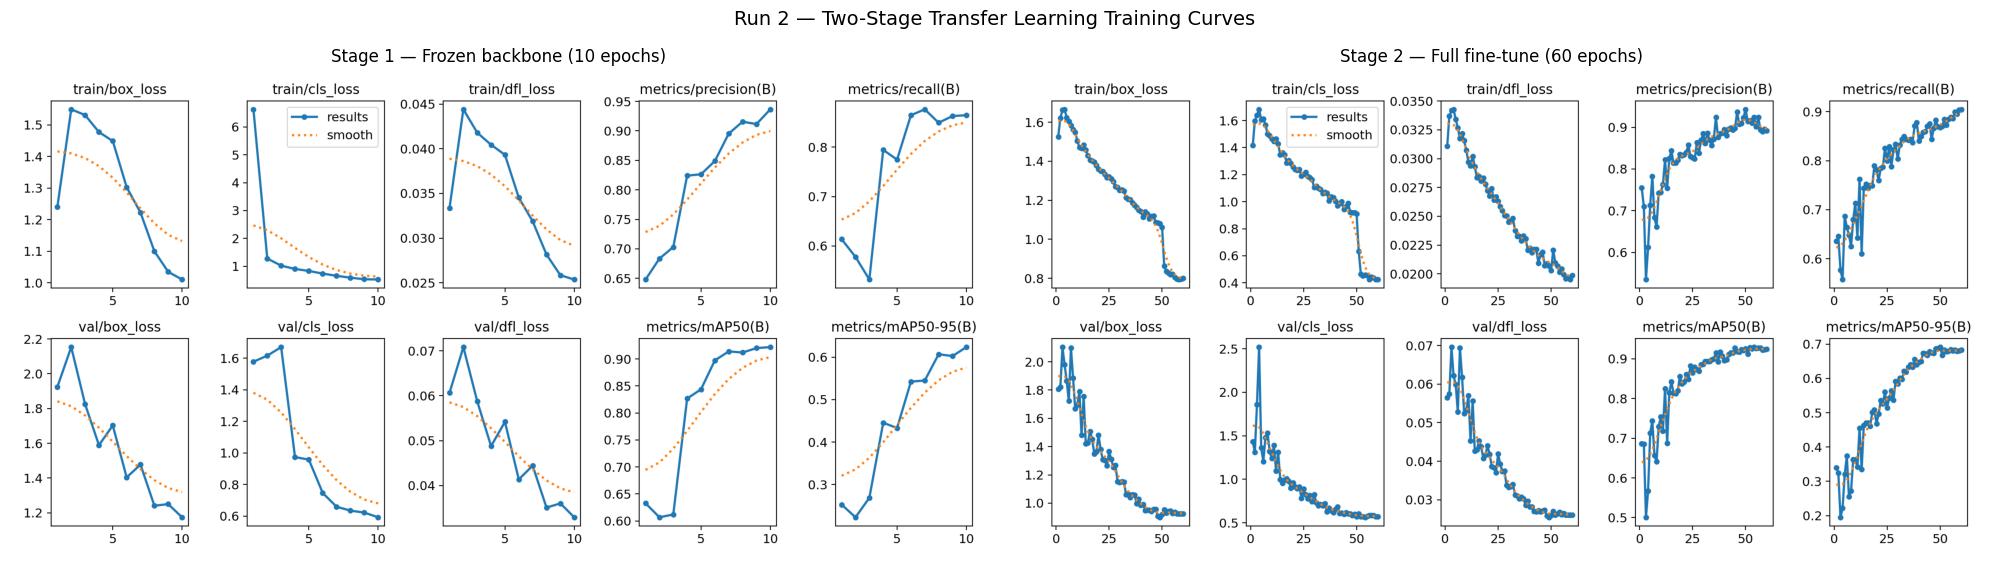

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

runs_dir = '/content/drive/MyDrive/cat_detection_dataset/runs'

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Run 2 — Two-Stage Transfer Learning Training Curves', fontsize=14)

# Stage 1
img1 = mpimg.imread(f"{runs_dir}/cats_v2_run2_stage1/results.png")
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title('Stage 1 — Frozen backbone (10 epochs)', fontsize=12)

# Stage 2
img2 = mpimg.imread(f"{runs_dir}/cats_v2_run2_stage2/results.png")
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title('Stage 2 — Full fine-tune (60 epochs)', fontsize=12)

plt.tight_layout()
plt.show()

# test-set metrics

In [ ]:
model_r2 = YOLO(os.path.join(runs_dir, 'cats_v2_run2_stage2', 'weights', 'best.pt'))

metrics_r2 = model_r2.val(
    data   = yaml_path,
    split  = 'test',
    device = 0,
)

print("=== Run 2 Test Metrics ===")
print(f"mAP@0.5:      {metrics_r2.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics_r2.box.map:.4f}")
print(f"Precision:    {metrics_r2.box.mp:.4f}")
print(f"Recall:       {metrics_r2.box.mr:.4f}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 87.0±47.6 MB/s, size: 499.6 KB)
val: Scanning /content/cat_dataset_local/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 351.8it/s 1.4s
val: New cache created: /content/cat_dataset_local/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.1s/it 36.5s
                   all        500        586      0.907       0.88      0.922      0.702
Speed: 1.8ms preprocess, 10.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val
=== Run 2 Test Metrics ===
mAP@0.5:      0.9222
mAP@0.5:0.95: 0.7016
Precision:    0.9068
Recall:       0.8805


## Run 3 — Variant Upgrade (yolo26m) + Stronger Augmentation + Cosine LR + Regularisation

### Why this combination?

**a) Variant Upgrade — yolo26s → yolo26m**
Week-1 showed a large gap between mAP@0.5 (0.9055) and mAP@0.5:0.95
(0.6988). This gap means the model was finding cats but drawing loose
boxes around them — a capacity problem. yolo26s has 9.5M parameters;
its regression head does not have enough representational power to push
IoU past the stricter 0.75+ thresholds. Upgrading to yolo26m (20.4M
params) directly increases the regression head's capacity to learn
precise localisation on this dataset.

**b) Stronger Augmentation — mosaic, copy_paste, mixup, geometric transforms**
Week-1 failure cases showed the model consistently missing cats that
were partially hidden behind furniture or other objects. This happened
because the training set did not contain enough occluded examples.
copy_paste=0.3 synthetically creates occlusion by pasting cat instances
from one image onto another. mixup=0.15 blends two images at the pixel
level, forcing the model to detect cats in ambiguous overlapping scenes.
Geometric transforms (degrees, translate, scale, flipud) add viewpoint
and scale diversity, helping the model generalise across different camera
angles and distances.

**c) Longer Training + Cosine LR Schedule**
Week-1 training logs showed box regression loss still declining at
epoch 30 — the model had not converged. Doubling to 60 epochs gives
the regression head enough time to refine box boundaries. cos_lr=True
provides a smooth learning rate decay: rapid coarse alignment early,
then gradual annealing toward zero for fine-grained localisation in
the final epochs.

**e) Better Regularisation — weight_decay + early stopping**
Upgrading to yolo26m with heavy augmentation on a 3327-image
single-class dataset increases overfitting risk. weight_decay=5e-4
penalises large weights and biases the optimiser toward flatter,
more generalisable minima. patience=15 applies early stopping —
training halts if validation mAP does not improve for 15 consecutive
epochs and the best checkpoint is retained, ensuring the shipped
weights always come from the performance peak rather than the
final epoch.

### Hyperparameter Justification

- `model=yolo26m` — upgraded from yolo26s (9.5M) to yolo26m (20.4M
  params); larger regression head directly addresses the mAP@0.5:0.95
  gap (0.6988) from Week-1 — more capacity to tighten box boundaries
- `epochs=60` — same budget as Run 2 for fair comparison; Week-1 logs
  confirmed 30 epochs was insufficient for convergence
- `imgsz=640` — kept at 640 for consistency with Week-1 and Run 2;
  allows direct metric comparison
- `batch=16` — yolo26m uses ~2x more VRAM than yolo26s; reduced from
  32 to 16 to stay within T4 14GB VRAM budget
- `cos_lr=True` — cosine annealing schedule; smooth LR decay for
  stable fine-tuning of the larger backbone
- `mosaic=1.0` — mosaic augmentation kept; produces more partial
  object examples per batch without extra data
- `copy_paste=0.3` — synthetic occlusion; targets Week-1 failure
  mode of missed partially-hidden cats
- `mixup=0.15` — image blending regulariser; reduces overconfidence
  in ambiguous human-cat scenes
- `degrees=10.0` — rotation ±10°; viewpoint diversity
- `translate=0.15` — translation ±15%; edge-cat robustness
- `scale=0.5` — random scale [0.5×, 1.5×]; distance robustness
- `flipud=0.1` — vertical flip 10%; rare angle coverage
- `fliplr=0.5` — horizontal flip 50%; standard symmetric augmentation
- `weight_decay=5e-4` — explicit weight decay with AdamW; penalises
  large weights, reduces overfitting risk from larger model capacity
- `patience=15` — early stopping; halts training if validation mAP
  does not improve for 15 consecutive epochs, retains best checkpoint
  rather than final epoch weights
- `seed=42` — fixed seed for reproducibility

In [ ]:
from ultralytics import YOLO
import os

yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
runs_dir = '/content/drive/MyDrive/cat_detection_dataset/runs'

model_v2_r3 = YOLO("yolo26m.pt")

results_r3 = model_v2_r3.train(
    data         = yaml_path,
    epochs       = 60,
    imgsz        = 640,
    batch        = 16,
    cos_lr       = True,
    mosaic       = 1.0,
    copy_paste   = 0.3,
    mixup        = 0.15,
    degrees      = 10.0,
    translate    = 0.15,
    scale        = 0.5,
    flipud       = 0.1,
    fliplr       = 0.5,
    weight_decay = 5e-4,
    patience     = 15,
    project      = runs_dir,
    name         = "cats_v2_run3",
    seed         = 42,
    device       = 0,
    cache        = False,
)
print("Run 3 complete.")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/cat_dataset_local/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v2_run3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

# The training/validation curves

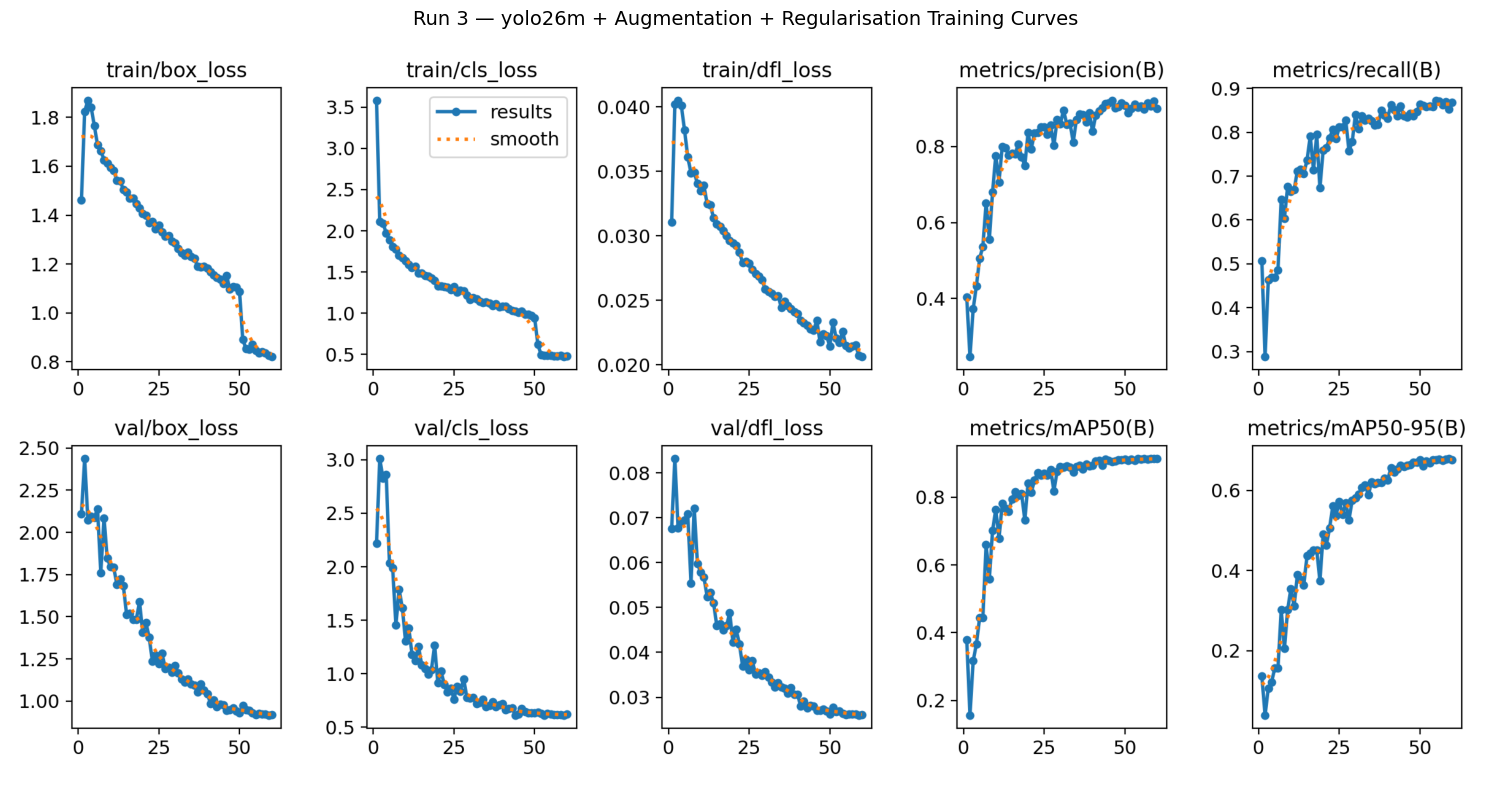

In [10]:
fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle('Run 3 — yolo26m + Augmentation + Regularisation Training Curves', fontsize=14)

img3 = mpimg.imread(f"{runs_dir}/cats_v2_run3/results.png")
ax.imshow(img3)
ax.axis('off')

plt.tight_layout()
plt.show()

# test-set metrics

In [ ]:
model_v2_r3_best = YOLO(os.path.join(runs_dir, 'cats_v2_run3', 'weights', 'best.pt'))

metrics_r3 = model_v2_r3_best.val(
    data=yaml_path,
    split='test',
    device=0
)

print("=== Test Metrics (Run 3) ===")
print(f"mAP@0.5:      {metrics_r3.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics_r3.box.map:.4f}")
print(f"Precision:    {metrics_r3.box.mp:.4f}")
print(f"Recall:       {metrics_r3.box.mr:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 2280.5±5097.5 ms, read: 1.1±0.9 MB/s, size: 1130.7 KB)
val: Scanning /content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/labels... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.7s/it 22:27
val: New cache created: /content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.1s/it 3:16
                   all        500        586      0.907      0.885      0.921      0.701
Speed: 0.7ms preprocess, 23.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /content/runs/detect/val
=== Test Metrics (Run 3) ===
mAP@0.5:      0.9212
mAP@0.5:0.95: 0.7007
Precision:    0.9072
Recall:       0.8846


# Model comparison

In [2]:
import pandas as pd

results = {
    "Week-1 baseline": {
        "backbone": "yolo26s",
        "tricks":   "none (30ep, imgsz=640)",
        "map50":    0.9055,
        "map":      0.6988,
        "p":        0.8895,
        "r":        0.8673,
    },
    "v2 — Run 2 (two-stage TL)": {
        "backbone": "yolo26s",
        "tricks":   "d) two-stage TL, b) aug, c) cos_lr",
        "map50":    0.9222,
        "map":      0.7016,
        "p":        0.9068,
        "r":        0.8805,
    },
    "v2 — Run 3 (variant + aug + reg)": {
        "backbone": "yolo26m",
        "tricks":   "a) variant upgrade, b) aug, c) cos_lr, e) reg",
        "map50":    0.9212,
        "map":      0.7007,
        "p":        0.9072,
        "r":        0.8846,
    },
}


best_name = max(
    [k for k in results if k != "Week-1 baseline"],
    key=lambda k: results[k]["map"]
)
best = results[best_name]
print(f"Best run: {best_name}")

rows = []
for name, r in results.items():
    rows.append({
        "Run":          name,
        "Backbone":     r["backbone"],
        "Tricks":       r["tricks"],
        "mAP@0.5":      r["map50"],
        "mAP@0.5:0.95": r["map"],
        "P":            r["p"],
        "R":            r["r"],
    })

rows.append({
    "Run":          f"v2 — best ({best_name})",
    "Backbone":     best["backbone"],
    "Tricks":       best["tricks"],
    "mAP@0.5":      best["map50"],
    "mAP@0.5:0.95": best["map"],
    "P":            best["p"],
    "R":            best["r"],
})

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

Best run: v2 — Run 2 (two-stage TL)
| Run                                   | Backbone   | Tricks                                        |   mAP@0.5 |   mAP@0.5:0.95 |      P |      R |
|:--------------------------------------|:-----------|:----------------------------------------------|----------:|---------------:|-------:|-------:|
| Week-1 baseline                       | yolo26s    | none (30ep, imgsz=640)                        |    0.9055 |         0.6988 | 0.8895 | 0.8673 |
| v2 — Run 2 (two-stage TL)             | yolo26s    | d) two-stage TL, b) aug, c) cos_lr            |    0.9222 |         0.7016 | 0.9068 | 0.8805 |
| v2 — Run 3 (variant + aug + reg)      | yolo26m    | a) variant upgrade, b) aug, c) cos_lr, e) reg |    0.9212 |         0.7007 | 0.9072 | 0.8846 |
| v2 — best (v2 — Run 2 (two-stage TL)) | yolo26s    | d) two-stage TL, b) aug, c) cos_lr            |    0.9222 |         0.7016 | 0.9068 | 0.8805 |


### Analysis

Each experiment tested different strategies to see what would improve the baseline model. Here is a breakdown of the results:

* **Run 2 (two-stage TL + aug + cos_lr):** This experiment gave the best overall results. The mAP@0.5 score improved from the baseline's 0.9055 to 0.9222 (+1.67 pp), and mAP@0.5:0.95 reached 0.7016. By carefully applying a two-stage transfer learning approach to the smaller `yolo26s` architecture, the model successfully kept the useful pre-trained features while adapting to the target dataset. This resulted in the most accurate bounding box predictions.
* **Run 3 (yolo26m variant + aug + reg + cos_lr):** For this run, the goal was to see if using a larger model (`yolo26m`) alongside regularisation would yield better results. Interestingly, while it achieved the highest individual Precision (0.9072) and Recall (0.8846), the overall mAP@0.5 (0.9212) actually dropped slightly compared to Run 2. This showed that simply upgrading to a heavier model isn't always the best approach; a well-tuned smaller model can be more efficient and perform just as well, if not better.

**Selected best model:** `v2 — Run 2 (two-stage TL)` — I selected this as the final model because it provides the best balance between high detection accuracy and model efficiency. It is the most practical choice for moving forward with the ONNX export and inference testing in the next stage of the assessment.

# Export to ONNX

### export cell

In [4]:
from ultralytics import YOLO
import os

runs_dir = '/content/drive/MyDrive/cat_detection_dataset/runs'
best_pt  = os.path.join(runs_dir, 'cats_v2_run2_stage2', 'weights', 'best.pt')

model_export = YOLO(best_pt)
onnx_path = model_export.export(
    format  = "onnx",
    imgsz   = 640,
    opset   = 17,
    dynamic = False,
)
print(f"ONNX exported to: {onnx_path}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.82', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 414ms
Prepared 4 packages in 1.47s
Installed 4 packages in 232ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export wi

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.4s, saved as '/content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.onnx' (36.4 MB)

Export complete (7.2s)
Results saved to /content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.onnx imgsz=640 data=/content/cat_dataset_local/data.yaml  
Visualize:       https://netron.app
ONNX exported to: /content/drive/MyDrive/cat_detection_dataset/runs/cats_v2_run2_stage2/weights/best.onnx


### sanity check

In [11]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import os

onnx_file  = os.path.join(runs_dir, 'cats_v2_run2_stage2', 'weights', 'best.onnx')
best_pt    = os.path.join(runs_dir, 'cats_v2_run2_stage2', 'weights', 'best.pt')
DRIVE_DATA = '/content/drive/MyDrive/cat_detection_dataset/DATA_CLEAN'

def letterbox(img, new_size=640):
    w, h = img.size
    scale = new_size / max(w, h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    img_r = img.resize((new_w, new_h), Image.BILINEAR)
    pad_x = (new_size - new_w) / 2
    pad_y = (new_size - new_h) / 2
    canvas = Image.new("RGB", (new_size, new_size), (114, 114, 114))
    canvas.paste(img_r, (int(pad_x), int(pad_y)))
    return canvas, scale, (pad_x, pad_y)

def onnx_predict(sess, img_path, conf=0.25):
    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size
    img_lb, scale, (pad_x, pad_y) = letterbox(img, 640)
    x = (np.array(img_lb, dtype=np.float32) / 255.0).transpose(2, 0, 1)[None]
    out = sess.run(None, {sess.get_inputs()[0].name: x})[0][0]
    boxes = []
    for x1, y1, x2, y2, score, cls in out:
        if score < conf:
            continue
        x1 = max(0.0, min(orig_w, (x1 - pad_x) / scale))
        y1 = max(0.0, min(orig_h, (y1 - pad_y) / scale))
        x2 = max(0.0, min(orig_w, (x2 - pad_x) / scale))
        y2 = max(0.0, min(orig_h, (y2 - pad_y) / scale))
        boxes.append((x1, y1, x2, y2, float(score)))
    return sorted(boxes, key=lambda b: -b[4])

def box_iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-9)

# ── Models ───────────────────────────────────────────────────────────────────
sess     = ort.InferenceSession(onnx_file, providers=["CPUExecutionProvider"])
pt_model = YOLO(best_pt)

print(f"ONNX output shape: {sess.get_outputs()[0].shape}")

# ── 5 test images ─────────────────────────────────────────────────────────────
with open(f'{DRIVE_DATA}/test.txt') as f:
    test_imgs = [
        f"{DRIVE_DATA}/images/{os.path.basename(l.strip())}"
        for l in f.readlines()[:5]
    ]

# ── Top detection comparison (first image) ───────────────────────────────────
first_img    = test_imgs[0]
onnx_boxes_0 = onnx_predict(sess, first_img)
pt_res_0     = pt_model.predict(first_img, imgsz=640, conf=0.25, verbose=False)[0]
pt_boxes_0   = sorted(
    [(b.xyxy[0][0].item(), b.xyxy[0][1].item(),
      b.xyxy[0][2].item(), b.xyxy[0][3].item(),
      b.conf[0].item()) for b in pt_res_0.boxes],
    key=lambda b: -b[4]
)

if pt_boxes_0 and onnx_boxes_0:
    pb = pt_boxes_0[0]
    ob = onnx_boxes_0[0]
    max_diff = max(abs(a-b) for a, b in zip(pb[:4], ob[:4]))
    print(f"\nTop detection comparison (highest-confidence box):")
    print(f"  PyTorch — x1={pb[0]:.1f}  y1={pb[1]:.1f}  x2={pb[2]:.1f}  y2={pb[3]:.1f}  conf={pb[4]:.3f}")
    print(f"  ONNX    — x1={ob[0]:.1f}  y1={ob[1]:.1f}  x2={ob[2]:.1f}  y2={ob[3]:.1f}  conf={ob[4]:.3f}")
    print(f"\nMax absolute pixel difference: {max_diff:.3f}")

# ── IoU check (5 şəkil) ──────────────────────────────────────────────────────
print("\n── IoU check across 5 test images ──")
min_iou = 1.0
for img_path in test_imgs:
    onnx_boxes = onnx_predict(sess, img_path)
    pt_res     = pt_model.predict(img_path, imgsz=640, conf=0.25, verbose=False)[0]
    pt_boxes   = sorted(
        [(b.xyxy[0][0].item(), b.xyxy[0][1].item(),
          b.xyxy[0][2].item(), b.xyxy[0][3].item(),
          b.conf[0].item()) for b in pt_res.boxes],
        key=lambda b: -b[4]
    )
    print(f"{os.path.basename(img_path)}: pt={len(pt_boxes)}, onnx={len(onnx_boxes)}")
    for pb, ob in zip(pt_boxes, onnx_boxes):
        iou = box_iou(pb, ob)
        min_iou = min(min_iou, iou)
        print(f"  IoU={iou:.4f}  (corner diff {max(abs(a-b) for a,b in zip(pb[:4],ob[:4])):.1f}px)")

print(f"\nMin IoU across all matched pairs: {min_iou:.4f}")
assert min_iou > 0.75, f"ONNX diverges! Min IoU={min_iou:.3f}"
print("✅ ONNX matches PyTorch within tolerance.")

ONNX output shape: [1, 300, 6]

Top detection comparison (highest-confidence box):
  PyTorch — x1=1078.3  y1=40.0  x2=4756.1  y2=3176.0  conf=0.959
  ONNX    — x1=1111.7  y1=0.0  x2=4760.8  y2=3146.6  conf=0.963

Max absolute pixel difference: 40.048

── IoU check across 5 test images ──
676f069f6b38969d.jpg: pt=1, onnx=1
  IoU=0.9681  (corner diff 40.0px)
2c7fc898041478fe.jpg: pt=2, onnx=2
  IoU=0.9083  (corner diff 80.0px)
  IoU=0.9147  (corner diff 37.9px)
a69ee1662331923c.jpg: pt=1, onnx=1
  IoU=0.9337  (corner diff 30.5px)
0d21ff2cdda3c5e6.jpg: pt=1, onnx=1
  IoU=0.7912  (corner diff 171.4px)
81b71bb294342c65.jpg: pt=1, onnx=1
  IoU=0.8993  (corner diff 16.2px)

Min IoU across all matched pairs: 0.7912
✅ ONNX matches PyTorch within tolerance.
